# Post-Hoc Model Explainability Lab: PDP, PFI, and ALE

## Introduction to Model Explainability (XAI)

In the field of machine learning, models are often referred to as "black boxes" because their internal workings and decision-making processes can be opaque. **Explainable Artificial Intelligence (XAI)** is a set of tools and techniques that allows us to understand how a model arrives at a particular decision.

Explainability can be categorized into two main types:
1.  **Global Explainability:** Aims to understand the overall behavior of the model across the entire dataset. It answers questions like "Which features are most important for the model's performance?" or "How does the model generally respond to changes in a specific feature?"
2.  **Local Explainability:** Focuses on understanding individual predictions. It answers questions like "Why did the model predict this specific price for this specific house?"

This lab focuses on **Global Post-Hoc Explainability**, which involves analyzing a trained model *after* it has been built. We will explore three powerful, model-agnostic techniques:

1.  **Permutation Feature Importance (PFI):** A global method to understand which features are most important to the model's overall performance.
2.  **Partial Dependence Plots (PDP):** A global method to visualize the marginal effect of one or two features on the predicted outcome.
3.  **Accumulated Local Effects (ALE):** An improved global method over PDP that accounts for feature correlation.

## Setup and Data Preparation

We will use the California Housing dataset, a classic regression problem, and train a black-box Random Forest model.

### 1. Install and Import Libraries

We will use `scikit-learn` for the model and PFI/PDP, and `PyALE` for the ALE plots.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from PyALE import ale

### 2. Load and Prepare Data

Features (X_train) head:
       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
14196  3.2596      33.0  5.017657   1.006421      2300.0  3.691814     32.71   
8267   3.8125      49.0  4.473545   1.041005      1314.0  1.738095     33.77   
17445  4.1563       4.0  5.645833   0.985119       915.0  2.723214     34.66   
14265  1.9425      36.0  4.002817   1.033803      1418.0  3.994366     32.69   
2271   3.5542      43.0  6.268421   1.134211       874.0  2.300000     36.78   

       Longitude  
14196    -117.03  
8267     -118.16  
17445    -120.48  
14265    -117.11  
2271     -119.80  


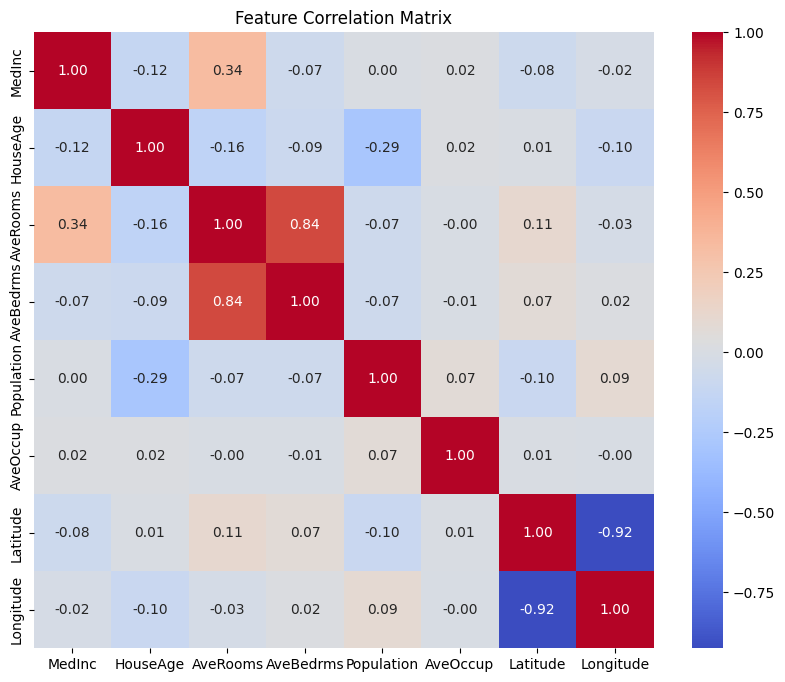

In [2]:
# Load the California Housing dataset
housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the first few rows of the feature data
print("Features (X_train) head:")
print(X_train.head())

# Check for correlation among features
plt.figure(figsize=(10, 8))
sns.heatmap(X_train.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

### 3. Train the Black-Box Model

We train a Random Forest Regressor, which is a powerful, non-linear model often considered a "black box."

In [3]:
# Initialize and train the Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Evaluate the model (R-squared score)
r_sq = model.score(X_test, y_test)
print(f"\nModel R-squared on test set: {r_sq:.4f}")


Model R-squared on test set: 0.8049


---

## Section 1: Permutation Feature Importance (PFI)

### Theory

**Permutation Feature Importance (PFI)** measures the importance of a feature by calculating the increase in the model's prediction error after permuting (shuffling) the feature's values. A feature is considered "important" if shuffling its values significantly increases the model's error, as the model relied on that feature for accurate predictions.

**Key Concept:** If a feature is important, breaking the relationship between the feature and the target (by shuffling) should confuse the model and lead to worse predictions. If a feature is unimportant, shuffling it shouldn't matter much.

#### Pros and Cons

| Pros | Cons |
| :--- | :--- |
| **Model-Agnostic:** Works with any model. | **Correlation Bias:** If features are correlated, shuffling one feature can create unrealistic data points (e.g., a pregnant man, or a 50 sq ft house with 10 rooms). This forces the model to extrapolate to unseen regions, potentially leading to misleading importance scores. |
| **Global Insight:** Provides a single score for each feature. | **Randomness:** Results can vary slightly between runs due to random shuffling (mitigated by repeating the process). |
| **Easy to Interpret:** Higher score = higher importance. | **No Directionality:** Tells you *that* a feature is important, but not *how* it affects the prediction (positive or negative relationship). |

### Implementation

We will use the `permutation_importance` function from `scikit-learn`.


Permutation Feature Importance Results:
      Feature  Importance Mean  Importance Std
7      MedInc         0.729892        0.014304
6    Latitude         0.444414        0.009475
5   Longitude         0.335167        0.005877
4    AveOccup         0.202855        0.005466
3    HouseAge         0.072213        0.004145
2    AveRooms         0.027430        0.002056
1   AveBedrms         0.009563        0.001509
0  Population         0.007819        0.001228


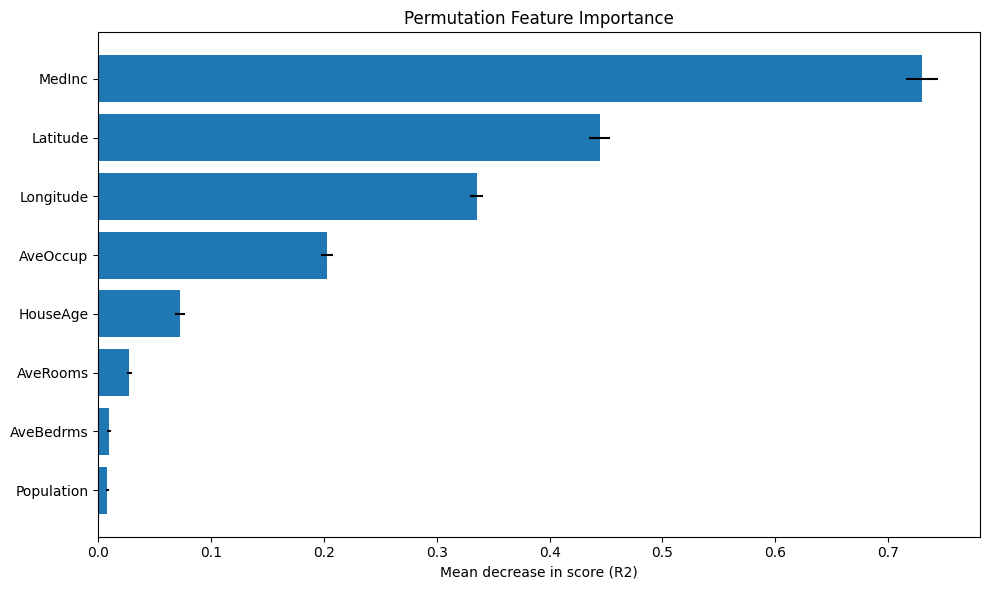

In [4]:
# Calculate Permutation Feature Importance
result = permutation_importance(
    model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1, scoring='r2'
)

# Organize results into a DataFrame
sorted_idx = result.importances_mean.argsort()
pfi_df = pd.DataFrame({
    'Feature': X_test.columns[sorted_idx],
    'Importance Mean': result.importances_mean[sorted_idx],
    'Importance Std': result.importances_std[sorted_idx]
})

print("\nPermutation Feature Importance Results:")
print(pfi_df.sort_values(by='Importance Mean', ascending=False))

# Visualize the PFI results
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(pfi_df['Feature'], pfi_df['Importance Mean'], xerr=pfi_df['Importance Std'])
ax.set_xlabel("Mean decrease in score (R2)")
ax.set_title("Permutation Feature Importance")
plt.tight_layout()
plt.show()

### Exercise 1: Interpreting PFI

1.  Based on the plot, which feature is the **most** important for predicting house prices?
2.  What does a negative importance value (if any) imply about a feature? (Hint: It means the feature is not useful, and the random shuffling actually improved the score by chance).
3.  Try changing the `scoring` parameter to `'r2'` and re-run the PFI calculation. How do the results change?

---

## Section 2: Partial Dependence Plots (PDP)

### Theory

**Partial Dependence Plots (PDP)** show the average marginal effect of one or two features on the predicted outcome of a machine learning model. It works by fixing the feature(s) of interest to a grid of values and averaging the model's predictions over all other features.

Mathematically, for a feature $x_S$ and other features $x_C$, the partial dependence function is:
$$ \hat{f}_{x_S}(x_S) = E_{x_C}[\hat{f}(x_S, x_C)] = \int \hat{f}(x_S, x_C) dP(x_C) $$

In practice, we estimate this by averaging the predictions for every instance in the dataset, forcing the feature of interest to take on a specific value $x$ while keeping all other features unchanged.

#### The Correlation Problem

**Limitation:** PDP assumes that the feature(s) of interest are **uncorrelated** with the other features. If features are highly correlated, the PDP will average predictions over unlikely or impossible data points.

**Example:** Imagine predicting house prices based on `Size` and `Number of Rooms`. These are positively correlated. To calculate the PDP for `Size` at 500 sq ft, we might force a mansion (which originally had 10 rooms) to have `Size=500`. A 500 sq ft house with 10 rooms is impossible. The model has never seen such data and its prediction will be a blind guess (extrapolation). Averaging these guesses can produce a misleading PDP curve.

#### Pros and Cons

| Pros | Cons |
| :--- | :--- |
| **Intuitive:** Shows the relationship (linear, non-linear, monotonic) between feature and target. | **Assumption of Independence:** Fails when features are correlated. |
| **Easy to Implement:** Available in many libraries (sklearn). | **Average Effect:** Hides heterogeneous effects (e.g., if a feature has a positive effect for half the data and negative for the other half, the PDP might show a flat line). |

### Implementation: 1D PDP

We will plot the partial dependence for the two most important features identified by PFI.

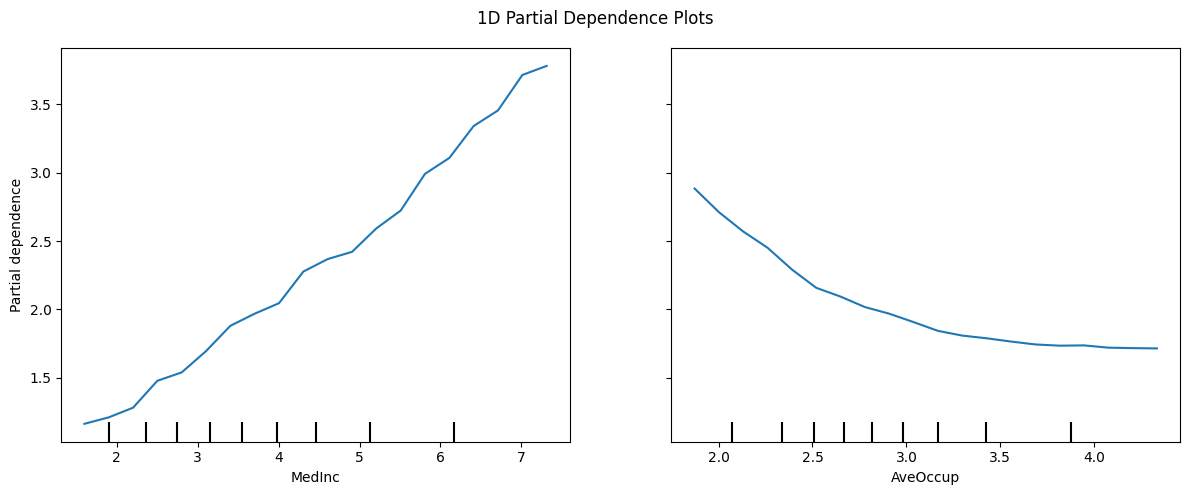

In [21]:
# Features to plot (e.g., the two most important)
features_to_plot_1d = ['MedInc', 'AveOccup']

# Create the PDP display
fig, ax = plt.subplots(figsize=(12, 5))
pdp_display = PartialDependenceDisplay.from_estimator(
    model,
    X_train,
    features=features_to_plot_1d,
    feature_names=X_train.columns.tolist(),
    target=0,
    n_jobs=-1,
    grid_resolution=20,
    kind='average', # only PDP
    ax=ax,
    subsample=1000
)
fig.suptitle("1D Partial Dependence Plots")
plt.tight_layout()
plt.show()

__Interpreting your figure (PDP-only)__:

* MedInc: monotonically increasing PDP → higher median income raises predicted target on average; effect strengthens at higher values (steeper slope).
AveOccup: decreasing PDP with flattening tail → higher average occupancy lowers predictions, with diminishing marginal effect after ≈3.2.



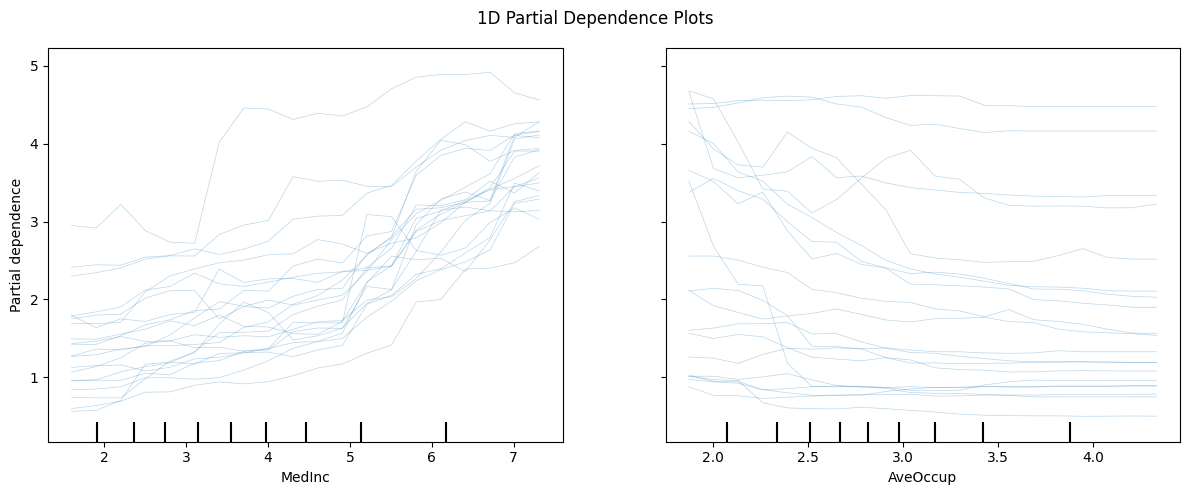

In [20]:
# Features to plot (e.g., the two most important)
features_to_plot_1d = ['MedInc', 'AveOccup']

# Create the PDP display
fig, ax = plt.subplots(figsize=(12, 5))
pdp_display = PartialDependenceDisplay.from_estimator(
    model,
    X_train,
    features=features_to_plot_1d,
    feature_names=X_train.columns.tolist(),
    target=0,
    n_jobs=-1,
    grid_resolution=20,
    kind='individual', # only ICE
    ax=ax,
    subsample=20
)
fig.suptitle("1D Partial Dependence Plots")
plt.tight_layout()
plt.show()

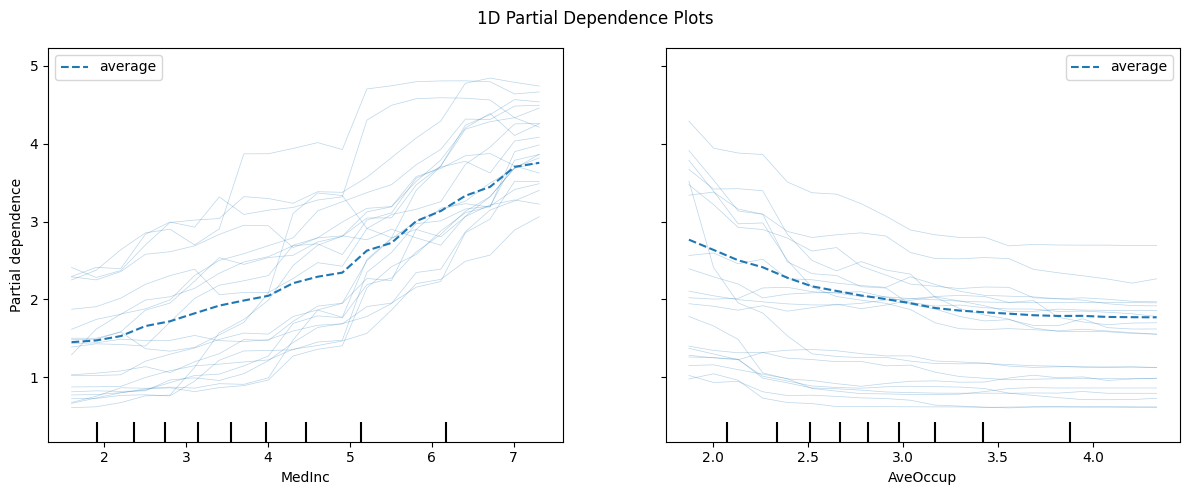

In [22]:
# Features to plot (e.g., the two most important)
features_to_plot_1d = ['MedInc', 'AveOccup']

# Create the PDP display
fig, ax = plt.subplots(figsize=(12, 5))
pdp_display = PartialDependenceDisplay.from_estimator(
    model,
    X_train,
    features=features_to_plot_1d,
    feature_names=X_train.columns.tolist(),
    target=0,
    n_jobs=-1,
    grid_resolution=20,
    kind='both', # both ICE  + PDB 
    subsample=20,
    ax=ax
)
fig.suptitle("1D Partial Dependence Plots")
plt.tight_layout()
plt.show()

* the blue dashed line: the average PDP 
* a LOT of faint lines: ICE curves (one line per sample, showing that sample’s prediction vs feature value)

### Implementation: 2D PDP (Feature Interaction)

We can also plot the joint dependence of two features to visualize their interaction.

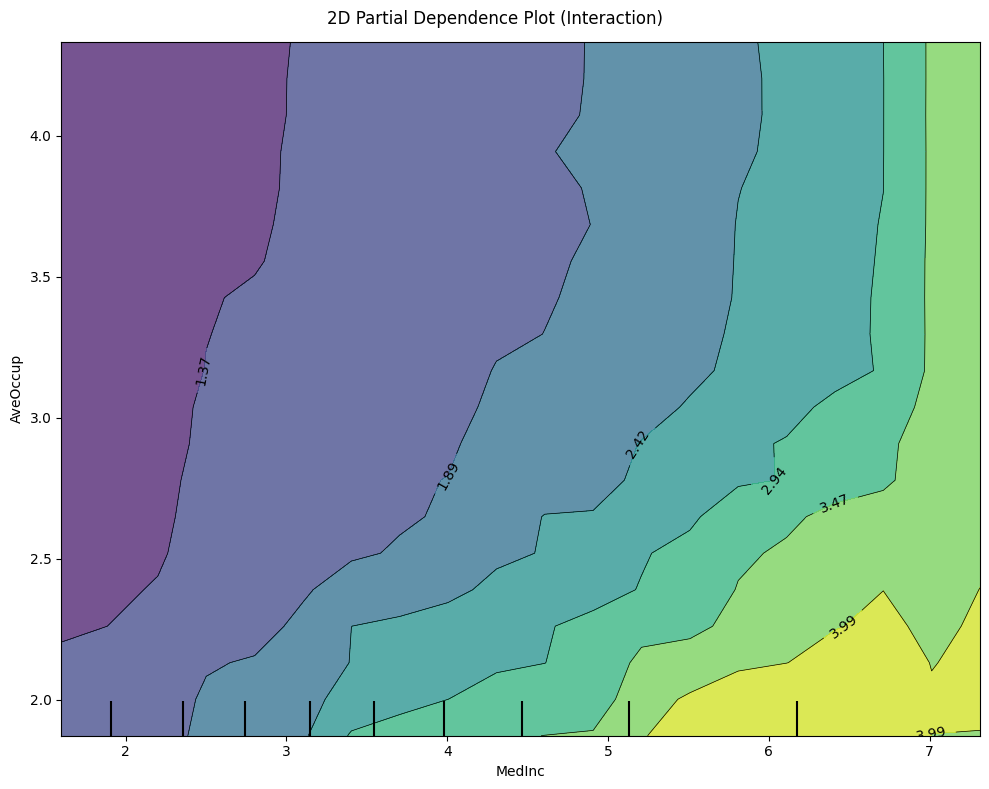

In [7]:
# Features to plot for 2D interaction
features_to_plot_2d = [('MedInc', 'AveOccup')]

# Create the 2D PDP display
fig, ax = plt.subplots(figsize=(10, 8))
pdp_display_2d = PartialDependenceDisplay.from_estimator(
    model,
    X_train,
    features=features_to_plot_2d,
    feature_names=X_train.columns.tolist(),
    target=0,
    n_jobs=-1,
    grid_resolution=20,
    ax=ax
)
fig.suptitle("2D Partial Dependence Plot (Interaction)")
plt.tight_layout()
plt.show()

* __2D PDP__: it shows how the model’s average prediction changes as MedInc and AveOccup vary together
* On average, the model predicts the highest values for high MedInc & low AveOccup, and the lowest for low MedInc & high AveOccup. Both matter, but MedInc has the dominant effect in this region

### Exercise 2: Interpreting PDP

1.  Describe the relationship between `MedInc` (Median Income) and the predicted house price based on the 1D PDP. Is it linear?
2.  Examine the 2D PDP for `MedInc` and `AveOccup` (Average Occupancy). Does the effect of `MedInc` on price appear to change significantly depending on the value of `AveOccup`? If so, describe the interaction.

---

## Section 3: Accumulated Local Effects (ALE)

### Theory

**Accumulated Local Effects (ALE)** plots are a more robust and less biased alternative to PDPs, especially when features are correlated. 

**How it works:**
Instead of replacing the feature value for *all* instances (like PDP), ALE calculates the difference in prediction (gradients) for instances that *already fall within a small window* around a specific feature value. It then accumulates (sums) these local differences to trace the effect curve.

**Why it solves the correlation problem:**
By using only instances that are locally close, ALE avoids creating impossible data combinations. For the "500 sq ft house" example, ALE would only look at houses that are already roughly 500 sq ft (which likely have 1-2 rooms, not 10). It calculates how the price changes for *those specific houses* if we tweak the size slightly. It never forces a mansion to be 500 sq ft.

**Interpretation:**
The y-axis of an ALE plot represents the **centered effect** of the feature on the prediction, compared to the average prediction. A value of 0 means the effect is equal to the average effect.

#### Pros and Cons

| Pros | Cons |
| :--- | :--- |
| **Handles Correlation:** Unbiased even with correlated features. | **Complexity:** Slightly harder to implement and explain than PDP. |
| **Faster:** often computationally faster than PDP (O(N) vs O(N*grid)). | **Interpretation:** The y-axis is relative (centered), not absolute predictions. |
| **Centered:** Shows effect relative to the mean prediction. | | 

### Implementation

We will use the `PyALE` library to generate the ALE plots.

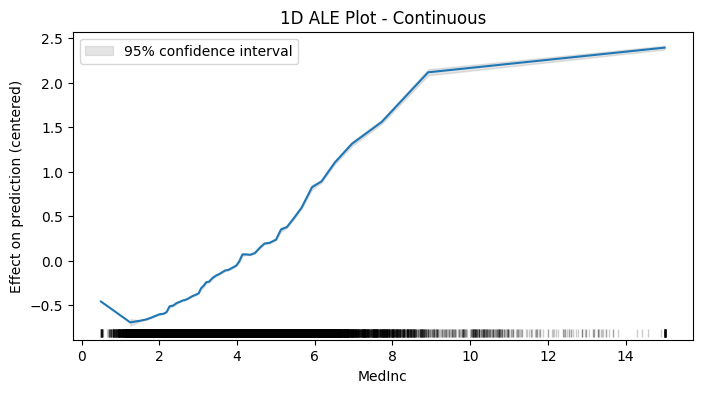

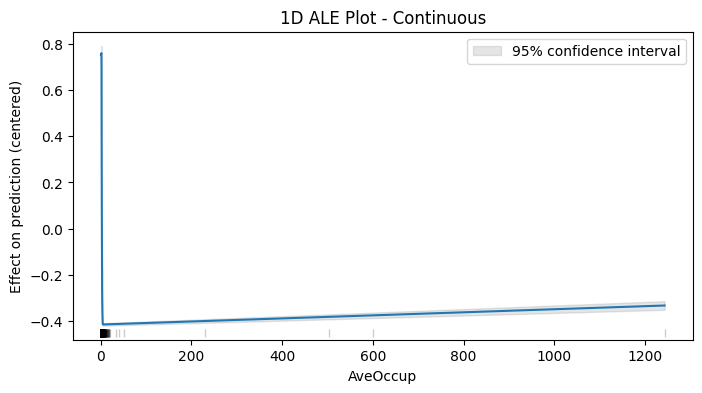

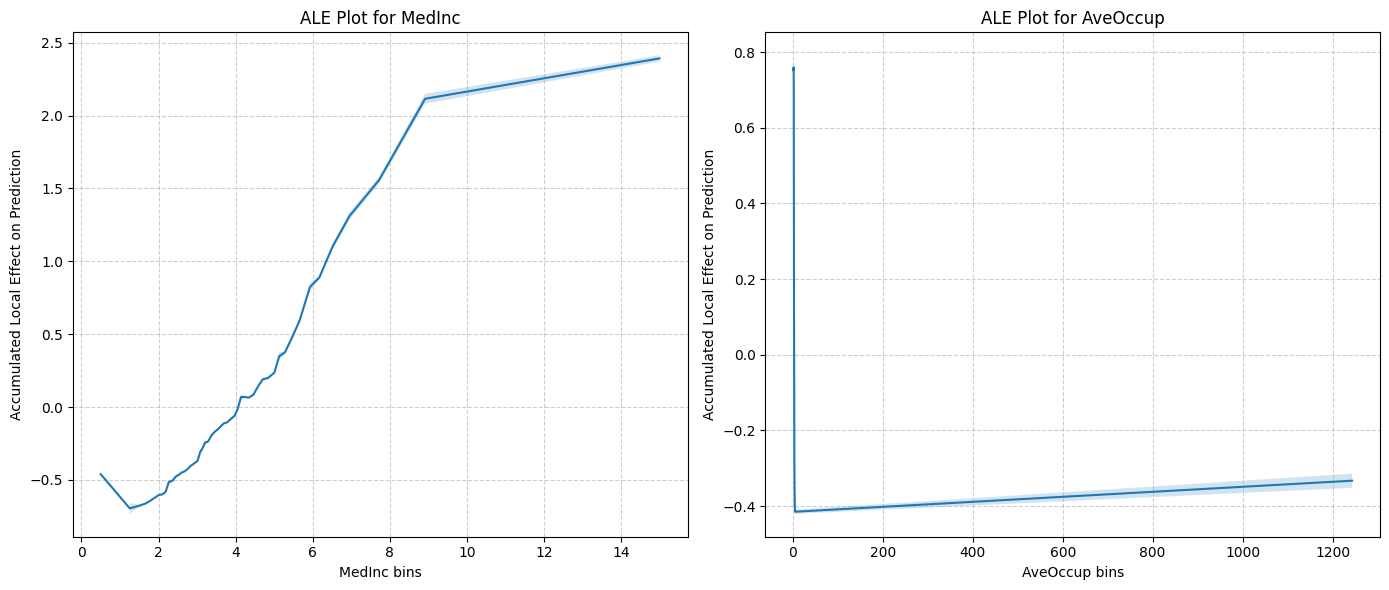

In [8]:
# Generate 1D ALE plots for the same features as PDP
ale_medinc = ale(
    X=X_train,
    model=model,
    feature=['MedInc'],
    feature_type='continuous',
    grid_size=50,
    include_CI=True
)

ale_aveoccup = ale(
    X=X_train,
    model=model,
    feature=['AveOccup'],
    feature_type='continuous',
    grid_size=50,
    include_CI=True
)

# Plotting the ALE results (PyALE returns a dictionary with plot data)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Build a simple x-axis from the bin index
x_medinc = ale_medinc.index
x_aveoccup = ale_aveoccup.index

# Plot MedInc ALE
axes[0].plot(x_medinc, ale_medinc['eff'], label='ALE')
axes[0].fill_between(
    x_medinc,
    ale_medinc['lowerCI_95%'],
    ale_medinc['upperCI_95%'],
    alpha=0.2,
    label='95% CI'
)
axes[0].set_title('ALE Plot for MedInc')
axes[0].set_xlabel('MedInc bins')
axes[0].set_ylabel('Accumulated Local Effect on Prediction')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot AveOccup ALE
axes[1].plot(x_aveoccup, ale_aveoccup['eff'], label='ALE')
axes[1].fill_between(
    x_aveoccup,
    ale_aveoccup['lowerCI_95%'],
    ale_aveoccup['upperCI_95%'],
    alpha=0.2,
    label='95% CI'
)
axes[1].set_title('ALE Plot for AveOccup')
axes[1].set_xlabel('AveOccup bins')
axes[1].set_ylabel('Accumulated Local Effect on Prediction')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [9]:
# Inspect columns once
print(ale_medinc.columns)
print(ale_aveoccup.columns)


Index(['eff', 'size', 'lowerCI_95%', 'upperCI_95%'], dtype='object')
Index(['eff', 'size', 'lowerCI_95%', 'upperCI_95%'], dtype='object')


### Exercise 3: Comparing PDP and ALE

1.  Compare the ALE plot for `MedInc` with its corresponding PDP. Are they similar? Why or why not?
2.  Compare the ALE plot for `AveOccup` with its corresponding PDP. Note any differences, especially in the shape or magnitude of the effect.
3.  Based on your observations, which technique (PDP or ALE) do you think provides a more reliable explanation for the effect of `AveOccup` on the predicted house price, and why?

---

## Conclusion and Further Reading

You have successfully implemented and interpreted three fundamental post-hoc explainability techniques: PFI, PDP, and ALE. Understanding these methods is crucial for building trust and gaining insights from complex machine learning models.

### Further Reading

*   **PiML Toolbox Documentation:** [https://selfexplainml.github.io/PiML-Toolbox/_build/html/guides/explain.html](https://selfexplainml.github.io/PiML-Toolbox/_build/html/guides/explain.html)
*   **Scikit-learn Model Inspection:** [https://scikit-learn.org/stable/inspection.html#](https://scikit-learn.org/stable/inspection.html#)
*   **Interpretable Machine Learning Book (Christoph Molnar):** A comprehensive resource for all XAI methods.
    *   Partial Dependence Plots: [https://christophm.github.io/interpretable-ml-book/pdp.html](https://christophm.github.io/interpretable-ml-book/pdp.html)
    *   Accumulated Local Effects: [https://christophm.github.io/interpretable-ml-book/ale.html](https://christophm.github.io/interpretable-ml-book/ale.html)
`